Đang huấn luyện mô hình Baseline (2 -> 4 -> 1)...
Đang huấn luyện mô hình Wide (2 -> 8 -> 1)...
Đang huấn luyện mô hình Deep (2 -> 8 -> 6 -> 1)...
Hoàn thành huấn luyện cả 3 mô hình!


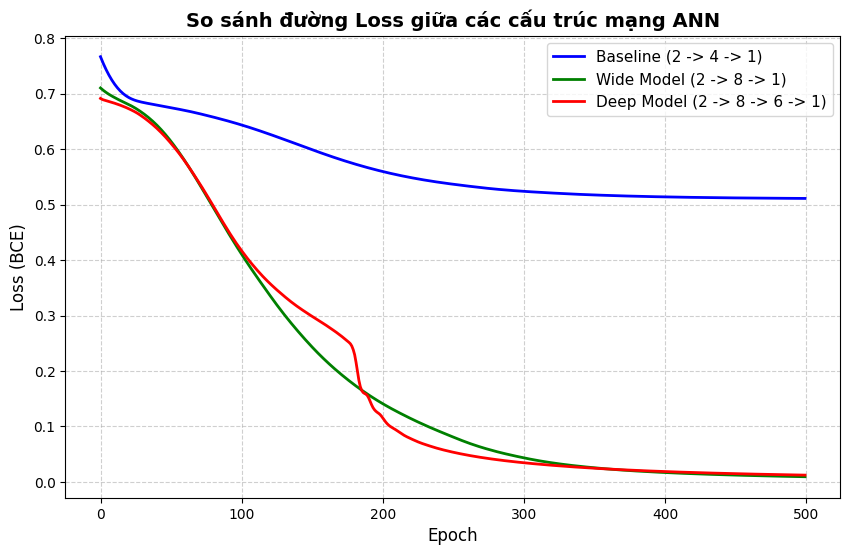

In [ ]:
#Phần 1
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles


torch.manual_seed(42)
np.random.seed(42)


X_np, y_np = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_seed=42) if 'random_seed' in make_circles.__code__.co_varnames else make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)


X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)


class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


class WideModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)


class DeepModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

def train_model(model, X, y, epochs=500, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    for epoch in range(epochs):
        model.train()


        outputs = model(X)
        loss = criterion(outputs, y)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        loss_history.append(loss.item())

    return loss_history


print("Đang huấn luyện mô hình Baseline (2 -> 4 -> 1)...")
baseline_model = BaselineModel()
baseline_losses = train_model(baseline_model, X, y)

print("Đang huấn luyện mô hình Wide (2 -> 8 -> 1)...")
wide_model = WideModel()
wide_losses = train_model(wide_model, X, y)

print("Đang huấn luyện mô hình Deep (2 -> 8 -> 6 -> 1)...")
deep_model = DeepModel()
deep_losses = train_model(deep_model, X, y)

print("Hoàn thành huấn luyện cả 3 mô hình!")


plt.figure(figsize=(10, 6))
plt.plot(baseline_losses, label='Baseline (2 -> 4 -> 1)', color='blue', linewidth=2)
plt.plot(wide_losses, label='Wide Model (2 -> 8 -> 1)', color='green', linewidth=2)
plt.plot(deep_losses, label='Deep Model (2 -> 8 -> 6 -> 1)', color='red', linewidth=2)

plt.title('So sánh đường Loss giữa các cấu trúc mạng ANN', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (BCE)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

Đang huấn luyện với Adam Optimizer...
Đang huấn luyện với SGD Optimizer (Momentum = 0.9)...
Hoàn thành huấn luyện cả 2 mô hình!


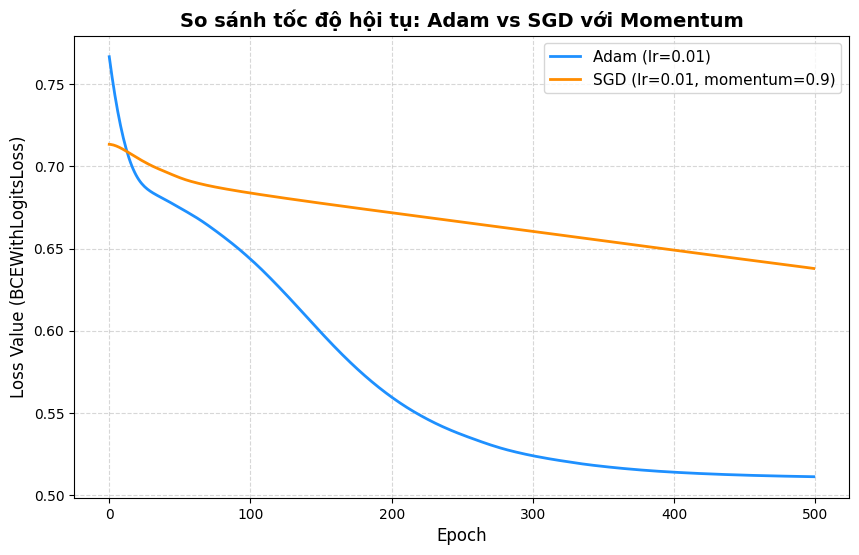


--- MINH HỌA CÁCH PREDICT ĐÚNG ---
Raw Logits (Đầu ra trực tiếp từ mạng):
 [ 0.5340446   1.866908    0.44935894  0.47544277 -1.2981945 ]
Probabilities (Sau khi bọc torch.sigmoid):
 [0.630426   0.8661001  0.6104868  0.6166712  0.21446903]
Predictions (Mẫu dự đoán: 1 nếu xác suất > 0.5, ngược lại 0):
 [1 1 1 1 0]
Ground Truth (Nhãn thực tế):
 [1. 1. 1. 1. 0.]


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

torch.manual_seed(42)
np.random.seed(42)

X_np, y_np = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)


class LogitsANNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x):
        return self.net(x)


def train_with_optimizer(optimizer_name, X, y, epochs=500, lr=0.01):
    model = LogitsANNModel()

    criterion = nn.BCEWithLogitsLoss()


    if optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    loss_history = []

    for epoch in range(epochs):
        model.train()

        logits = model(X)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

    return model, loss_history

print("Đang huấn luyện với Adam Optimizer...")
model_adam, losses_adam = train_with_optimizer('Adam', X, y)

print("Đang huấn luyện với SGD Optimizer (Momentum = 0.9)...")
model_sgd, losses_sgd = train_with_optimizer('SGD', X, y)

print("Hoàn thành huấn luyện cả 2 mô hình!")


plt.figure(figsize=(10, 6))
plt.plot(losses_adam, label='Adam (lr=0.01)', color='dodgerblue', linewidth=2)
plt.plot(losses_sgd, label='SGD (lr=0.01, momentum=0.9)', color='darkorange', linewidth=2)

plt.title('So sánh tốc độ hội tụ: Adam vs SGD với Momentum', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss Value (BCEWithLogitsLoss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()


model_adam.eval()
with torch.no_grad():
    test_logits = model_adam(X[:5])
    probabilities = torch.sigmoid(test_logits)
    predictions = (probabilities > 0.5).int()

print("\n--- MINH HỌA CÁCH PREDICT ĐÚNG ---")
print("Raw Logits (Đầu ra trực tiếp từ mạng):\n", test_logits.numpy().flatten())
print("Probabilities (Sau khi bọc torch.sigmoid):\n", probabilities.numpy().flatten())
print("Predictions (Mẫu dự đoán: 1 nếu xác suất > 0.5, ngược lại 0):\n", predictions.numpy().flatten())
print("Ground Truth (Nhãn thực tế):\n", y[:5].numpy().flatten())

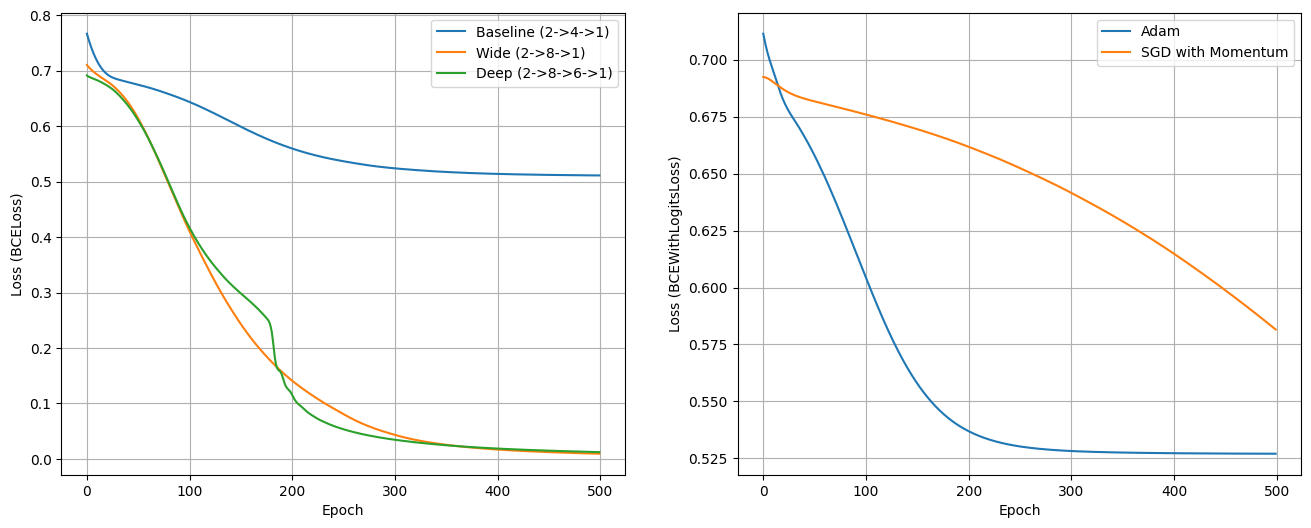

/tmp/ipykernel_12889/4079644683.py:174: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))


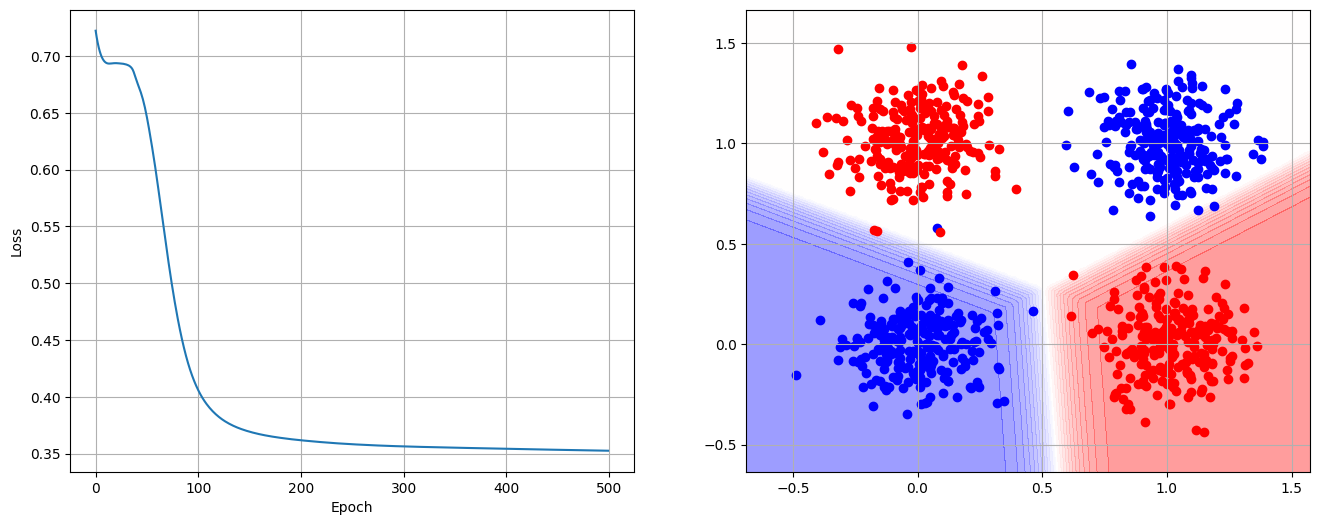

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

# ---------------------------------------------------------
# SETUP & DATA
# ---------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

X_np, y_np = make_circles(n_samples=1000, noise=0.05, factor=0.5, random_state=42)

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)

# ---------------------------------------------------------
# MODELS (PART 1 & PART 2)
# ---------------------------------------------------------
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class WideModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class DeepModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, 6),
            nn.ReLU(),
            nn.Linear(6, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

class LogitsModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x):
        return self.net(x)

# ---------------------------------------------------------
# TRAIN FUNCTIONS
# ---------------------------------------------------------
def train_model(model, X, y, epochs=500, lr=0.01):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    for epoch in range(epochs):
        model.train()
        outputs = model(X)
        loss = criterion(outputs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return loss_history

def train_with_optimizer(optimizer_type, X, y, epochs=500, lr=0.01):
    model = LogitsModel()
    criterion = nn.BCEWithLogitsLoss()
    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_history = []
    for epoch in range(epochs):
        model.train()
        logits = model(X)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return loss_history

# ---------------------------------------------------------
# EXECUTION & PLOTS (PART 1 & PART 2)
# ---------------------------------------------------------
baseline_losses = train_model(BaselineModel(), X, y)
wide_losses = train_model(WideModel(), X, y)
deep_losses = train_model(DeepModel(), X, y)

losses_adam = train_with_optimizer('Adam', X, y)
losses_sgd = train_with_optimizer('SGD', X, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(baseline_losses, label='Baseline (2->4->1)')
ax1.plot(wide_losses, label='Wide (2->8->1)')
ax1.plot(deep_losses, label='Deep (2->8->6->1)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (BCELoss)')
ax1.grid(True)
ax1.legend()

ax2.plot(losses_adam, label='Adam')
ax2.plot(losses_sgd, label='SGD with Momentum')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (BCEWithLogitsLoss)')
ax2.grid(True)
ax2.legend()
plt.show()

# ---------------------------------------------------------
# PART 4: XOR PROBLEM
# ---------------------------------------------------------
n_samples_per_cluster = 250
cluster_00 = np.random.normal(loc=[0, 0], scale=0.15, size=(n_samples_per_cluster, 2))
cluster_11 = np.random.normal(loc=[1, 1], scale=0.15, size=(n_samples_per_cluster, 2))
cluster_10 = np.random.normal(loc=[1, 0], scale=0.15, size=(n_samples_per_cluster, 2))
cluster_01 = np.random.normal(loc=[0, 1], scale=0.15, size=(n_samples_per_cluster, 2))

X_xor = torch.tensor(np.vstack((cluster_00, cluster_11, cluster_10, cluster_01)), dtype=torch.float32)
y_xor = torch.tensor(np.vstack((np.zeros((500, 1)), np.ones((500, 1)))), dtype=torch.float32)

class XORModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x):
        return self.net(x)

xor_model = XORModel()
xor_criterion = nn.BCEWithLogitsLoss()
xor_optimizer = optim.Adam(xor_model.parameters(), lr=0.02)
xor_losses = []

for epoch in range(500):
    xor_model.train()
    logits = xor_model(X_xor)
    loss = xor_criterion(logits, y_xor)
    xor_optimizer.zero_grad()
    loss.backward()
    xor_optimizer.step()
    xor_losses.append(loss.item())

xor_model.eval()
x_min, x_max = X_xor[:, 0].min() - 0.2, X_xor[:, 0].max() + 0.2
y_min, y_max = X_xor[:, 1].min() - 0.2, X_xor[:, 1].max() + 0.2
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    grid_probs = torch.sigmoid(xor_model(grid_tensor)).reshape(xx.shape).numpy()

fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6))

ax3.plot(xor_losses)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Loss')
ax3.grid(True)

ax4.contourf(xx, yy, grid_probs, levels=25, cmap='bwr', alpha=0.4)
ax4.scatter(X_xor[:500, 0].numpy(), X_xor[:500, 1].numpy(), c='blue')
ax4.scatter(X_xor[500:, 0].numpy(), X_xor[500:, 1].numpy(), c='red')
ax4.grid(True)
plt.show()